Nome: Agiana da Silva

Github: https://github.com/janiramarques7-cpu/TP-547-Principios-de-Simulacao-em-Sistemas-de-Telecomunicacoes

1ª Questão

N=100: Estimativa=0.392579, Erro=0.006284
N=1000: Estimativa=0.382964, Erro=0.003330
N=10000: Estimativa=0.386611, Erro=0.000316
N=100000: Estimativa=0.387143, Erro=0.000849


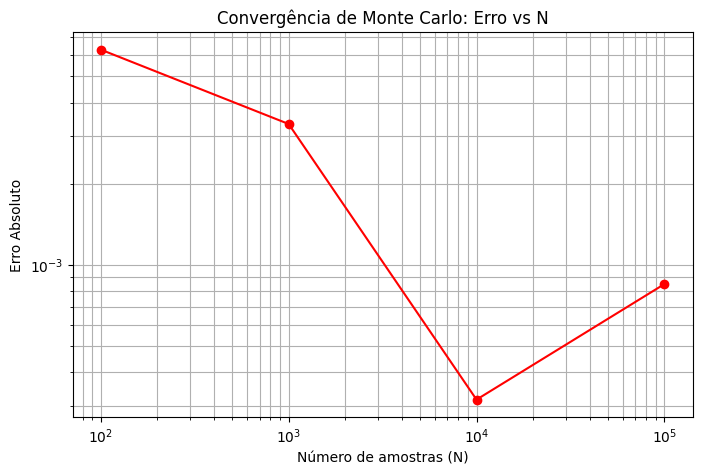

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Valor exato
I_real = 2 * np.log(2) - 1

# Parâmetros
Ns = [10**2, 10**3, 10**4, 10**5]
estimativas = []
erros = []

for N in Ns:
    # (a) Amostragem uniforme entre 0 e 1
    x = np.random.uniform(0, 1, N)
    # Cálculo da média da função ln(1+x)
    I_hat = np.mean(np.log(1 + x))

    estimativas.append(I_hat)
    erros.append(abs(I_real - I_hat))
    print(f"N={N}: Estimativa={I_hat:.6f}, Erro={abs(I_real - I_hat):.6f}")

# (c) Plotar o erro absoluto
plt.figure(figsize=(8, 5))
plt.loglog(Ns, erros, marker='o', linestyle='-', color='red')
plt.xlabel('Número de amostras (N)')
plt.ylabel('Erro Absoluto')
plt.title('Convergência de Monte Carlo: Erro vs N')
plt.grid(True, which="both", ls="-")
plt.show()

2ª Questão

In [1]:
import numpy as np

# 1. Definição da função original f(x)
def f(x):
    return 1 / (1 + x)**2

n = 100000  # Número de amostras
valor_real = 0.5

# (a) Monte Carlo Simples (Distribuição Uniforme) ---
x_uni = np.random.uniform(0, 1, n)
estimativa_simples = np.mean(f(x_uni))
variancia_simples = np.var(f(x_uni))

# (b/c) Importance Sampling ---
# Escolha de p(x) = (4 - 2x) / 3
# Esta p(x) é maior perto de x=0, onde f(x) também é maior.
def p(x):
    return (4 - 2*x) / 3

u = np.random.uniform(0, 1, n)
x_is = 2 - np.sqrt(4 - 3*u)

# Estimador de Importance Sampling: f(x) / p(x)
estimativa_is = np.mean(f(x_is) / p(x_is))
variancia_is = np.var(f(x_is) / p(x_is))

# --- (d) Resultados e Comparação ---
print(f"Valor Real da Integral: {valor_real}")
print("-" * 30)
print(f"Monte Carlo Simples:    {estimativa_simples:.5f} (Variância: {variancia_simples:.6f})")
print(f"Importance Sampling:    {estimativa_is:.5f} (Variância: {variancia_is:.6f})")
print("-" * 30)
print(f"Redução de Variância:   {(1 - variancia_is/variancia_simples)*100:.2f}%")

Valor Real da Integral: 0.5
------------------------------
Monte Carlo Simples:    0.49951 (Variância: 0.041821)
Importance Sampling:    0.50016 (Variância: 0.011856)
------------------------------
Redução de Variância:   71.65%


3ª Questão

Taxa de Aceitação Observada: 0.3296
Taxa de Aceitação Teórica (1/M): 0.3333


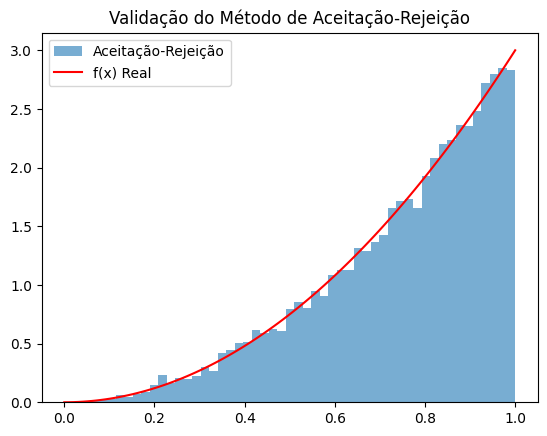

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Definição da função alvo f(x)
def f(x):
    return 3 * x**2

n_amostras = 10000
M = 3  # Valor máximo da função no intervalo [0,1]

# --- (a) Implementação Aceitação-Rejeição ---
amostras_ar = []
tentativas = 0

while len(amostras_ar) < n_amostras:
    x_cand = np.random.uniform(0, 1)  # Candidato da g(x) uniforme
    u = np.random.uniform(0, 1)       # Variável para teste de aceitação
    tentativas += 1

    if u <= f(x_cand) / M:
        amostras_ar.append(x_cand)

amostras_ar = np.array(amostras_ar)

# --- (b) Taxa de Aceitação ---
taxa_aceitacao = len(amostras_ar) / tentativas

# --- (c) Método da Inversa (Teórico para comparação) ---
# F(x) = x^3  =>  F^-1(u) = u^(1/3)
u_inversa = np.random.uniform(0, 1, n_amostras)
amostras_inv = u_inversa**(1/3)

# --- Exibição dos Resultados ---
print(f"Taxa de Aceitação Observada: {taxa_aceitacao:.4f}")
print(f"Taxa de Aceitação Teórica (1/M): {1/M:.4f}")

# Histograma para validar
plt.hist(amostras_ar, bins=50, density=True, alpha=0.6, label='Aceitação-Rejeição')
x_plot = np.linspace(0, 1, 100)
plt.plot(x_plot, f(x_plot), 'r', label='f(x) Real')
plt.legend()
plt.title("Validação do Método de Aceitação-Rejeição")
plt.show()

4ª Questão

In [3]:
import numpy as np

def simular_cartas(com_reposicao=False, n_simulacoes=100000):
    # Criamos o baralho: 0=A, 1=B, 2=C, 3=D (12 de cada)
    baralho = np.array([0]*12 + [1]*12 + [2]*12 + [3]*12)
    sucessos = 0

    for _ in range(n_simulacoes):
        if com_reposicao:
            # Sorteia 7 índices com reposição
            amostra = np.random.choice(baralho, size=7, replace=True)
        else:
            # Sorteia 7 índices sem reposição
            amostra = np.random.choice(baralho, size=7, replace=False)

        # Verifica se tem pelo menos um B (tipo 1) E pelo menos um D (tipo 3)
        tem_B = 1 in amostra
        tem_D = 3 in amostra

        if tem_B and tem_D:
            sucessos += 1

    return sucessos / n_simulacoes

# Execução das simulações
prob_sem = simular_cartas(com_reposicao=False)
prob_com = simular_cartas(com_reposicao=True)

print(f"--- Resultados da Simulação ---")
print(f"(a) Probabilidade SEM reposição: {prob_sem:.4f}")
print(f"(b) Probabilidade COM reposição: {prob_com:.4f}")

--- Resultados da Simulação ---
(a) Probabilidade SEM reposição: 0.7779
(b) Probabilidade COM reposição: 0.7407


Alínea a) da 5ª Questão

In [ ]:
import random

def simular_monte_carlo(n_simulacoes=10000):
    sucessos = 0
    for _ in range(n_simulacoes):
        dado1 = random.randint(1, 6)
        dado2 = random.randint(1, 6)
        if (dado1 + dado2) > 9:
            sucessos += 1
    return sucessos / n_simulacoes

estimativa = simular_monte_carlo(10000)
print(f"Probabilidade estimada: {estimativa:.4f}")

Probabilidade estimada: 0.1648
